In [1]:
# !apt-get install gcc 
# !apt-get install -y cmake 

# try:
#     import uv
# except:
#     %pip install -q uv

In [2]:
try:
    import xlearn
except:
    !uv pip install --system -U xlearn
    import xlearn

Using Python 3.12.13 environment at: /usr
Resolved 1 package in 1.49s
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building xlearn==0.40a1
   Building 

/usr/local/lib/python3.12/dist-packages/xlearn/_sklearn.py:327: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if self.model_type is not 'ffm':


In [3]:
!pip show gcc cmake

Name: cmake
Version: 3.31.10
Summary: CMake is an open-source, cross-platform family of tools designed to build, test and package software
Home-page: https://cmake.org
Author: 
Author-email: Jean-Christophe Fillion-Robin <jchris.fillionr@kitware.com>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [4]:
# %reset -f

In [5]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [6]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

# import tensorflow as tf

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize #, TargetEncoder
from sklearn.metrics import roc_auc_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay

import warnings

In [7]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [8]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## ----------------------------------------------------------------------------------------

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): 
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [9]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [10]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


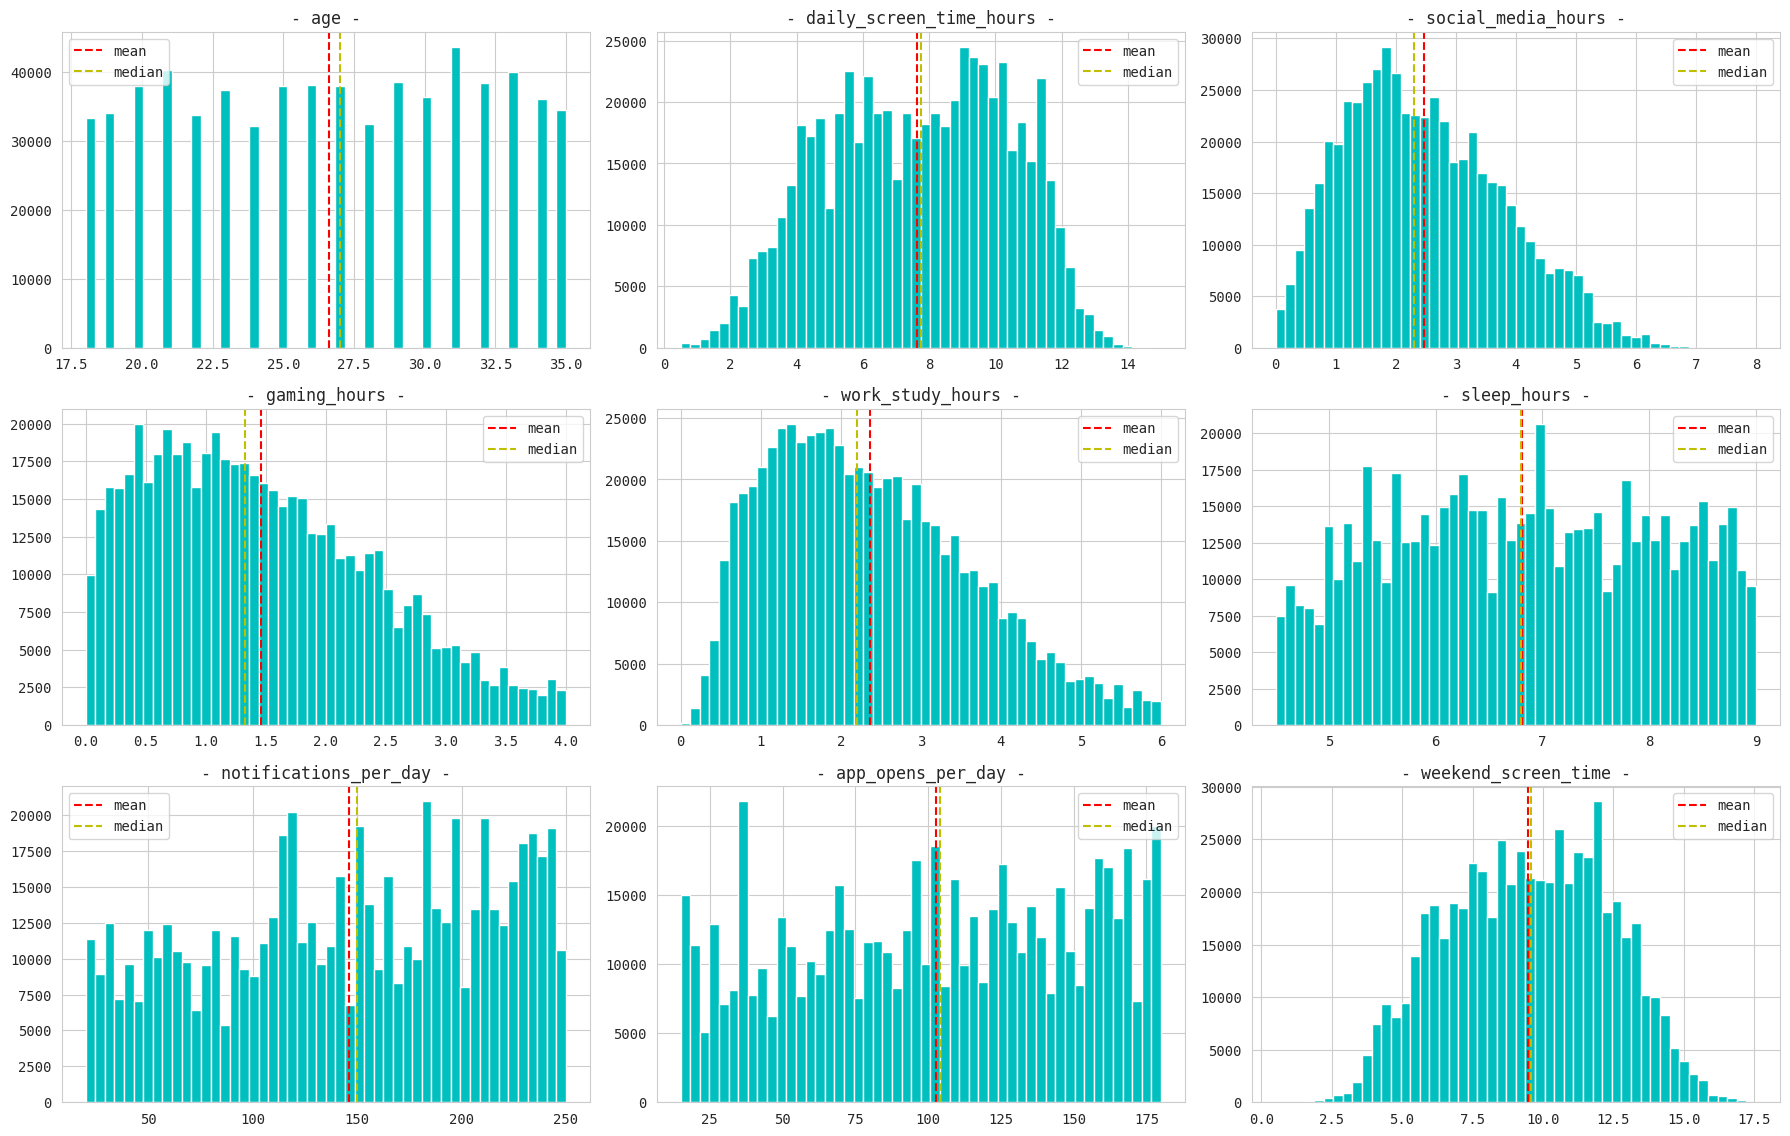

In [11]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [12]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Orig,Test
age,18,18,18
daily_screen_time_hours,1389,900,1349
social_media_hours,721,551,703
gaming_hours,401,401,401
work_study_hours,600,551,601
sleep_hours,451,451,451
notifications_per_day,231,231,231
app_opens_per_day,166,166,166
weekend_screen_time,1437,1096,1404
gender,3,3,3


In [13]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [14]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print("- Sample_Weight function ready -")

- Sample_Weight function ready -


In [15]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [16]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [17]:
CATS.extend(ROUNDS+DIGITS+E_BINS+Q_BINS)

train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [18]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [19]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [20]:
# ## -- Arithmetic features --

# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [21]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [22]:
# train['MonthlyCharges'].rolling(window=10000).mean().plot(figsize=(20, 5))

In [23]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end="")
# for col in NUMS:
#     freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
#     n = f"{col}_FREQ"
#     print(n+", ", end="")
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype("float32")
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

# train[NUMS+FREQ_COLS]

In [24]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [25]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    num_to_cat = []
    for col in num_features_:
        cat_name = f"{col}_cat"
        df[cat_name] = df[col].fillna('NaN').astype(str)
        num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')
    
    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('int8')
        
    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)
    
    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    elif TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols

train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

new_cats = ["missing_count"]
new_cats.extend([
    c for c in FE_COLS
    if "_round" in c
    or c.endswith("_cat")
    or c.startswith("ci_")
])
# new_cats.extend([c for c in FE_COLS if train[c].nunique() < 1_000])

new_nums = [c for c in FE_COLS if c not in new_cats]

# train[NEW_CATS] = train[NEW_CATS].astype(int) #.fillna(-1)
# test[NEW_CATS]  = test[NEW_CATS].astype(int) #.fillna(-1)
# orig[NEW_CATS]  = orig[NEW_CATS].fillna(-1)

CATS.extend(new_cats)
# NUMS.extend(NEW_NUMS)

train[new_cats+new_nums]

,missing_count,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,addicted_label,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour
0,1,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,NaN,1.86,0.93,1.86,NaN,2.0,1.0,0,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297
2,3,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,NaN,NaN,NaN,NaN,NaN,0.0,3.0,0,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078
3,1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456
4,2,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,NaN,NaN,NaN,NaN,4.57,0.0,0.0,1,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,1,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729
691365,0,20.0,3.45,1.86,0.89,0.3,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,NaN,NaN,NaN,NaN,0.40,0.0,0.0,1,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785
691366,5,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.1,6.0,6.2,NaN,NaN,86.0,86.0,8.0,7.8,NaN,NaN,NaN,NaN,NaN,0.0,3.0,1,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
691367,2,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,22.0,22.0,12.0,11.8,4.0,3.7,0.0,0.2,1.0,1.4,6.0,5.5,171.0,171.0,62.0,62.0,8.0,7.7,NaN,NaN,NaN,NaN,6.51,0.0,0.0,1,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117


In [26]:
train[FE_COLS].nunique()

addicted_label                         2
age_cat                               19
daily_screen_time_hours_cat         1390
social_media_hours_cat               722
gaming_hours_cat                     402
work_study_hours_cat                 601
sleep_hours_cat                      452
notifications_per_day_cat            232
app_opens_per_day_cat                167
weekend_screen_time_cat             1438
age_round0                            18
age_round1                            18
daily_screen_time_hours_round0        16
daily_screen_time_hours_round1       146
social_media_hours_round0              9
social_media_hours_round1             81
gaming_hours_round0                    5
gaming_hours_round1                   41
work_study_hours_round0                7
work_study_hours_round1               61
sleep_hours_round0                     6
sleep_hours_round1                    46
notifications_per_day_round0         231
notifications_per_day_round1         231
app_opens_per_da

In [27]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [28]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [30]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [31]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["mean", "count"]

# train, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = orig_TE_data_propagate(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [32]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

# combined = pd.concat([train, test, orig])
# ## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS):
#     n = f"cat_{c}"
#     combined[n] = combined[c].copy()
#     CATS_2.append(n)
# CATS.extend(CATS_2)
# FEATURES.extend(CATS_2)
# ## ------------------------------------------------------------
# ## -- Factorize all CATS data --
# for c in CATS:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')

# train = combined.iloc[:len(train)][FEATURES+[TARGET]]
# test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
# orig  = combined.iloc[len(train)+len(test):]

# del combined
# print("Label encoding complete!")
# print("Total Features:", len(FEATURES))

# train

In [33]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 56


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2


In [34]:
# ## -- Convert pandas dataframe to .libffm file --
# from collections import defaultdict

# field_features = defaultdict()

# def df_to_libffm(df, cats, nums, target, save_file=f"df_converted.libffm"):
#     '''
#     Converts pandas dataframe to libffm formats, with feature dimension casting.
#     '''
#     categories       = cats
#     categories_index = dict(zip(categories, range(len(categories))))
#     max_val          = 1

#     with open(save_file, 'a') as the_file:
#         for t in tqdm(range(len(df))):
#             row = df.iloc[t]
#             label = [str(int(row[target]))]
#             ffeatures = []
#             for field in categories:
#                 if field == target:
#                     continue 
#                 feature = row[field]
#                 if field not in nums:
#                     ff = field + '_____' + str(feature)
#                     value = 1
#                 else:
#                     ff = field + '_____' + str(0)
#                     value = feature
#                 if ff not in field_features:
#                     if len(field_features) == 0:
#                         field_features[ff] = 1
#                         max_val = max_val + 1
#                     else:
#                         field_features[ff] = max_val + 1
#                         max_val = max_val + 1
#                 fnum = field_features[ff]
#                 ffeatures.append('{}:{}:{}'.format(categories_index[field],fnum,value))
#             line = label + ffeatures
#             the_file.write('{}\n'.format(' '.join(line)))

In [35]:
# ==================================================================  
# OPTIMIZED df_to_libffm  
# ==================================================================  
_FEATURE_MAP = {}  # feature-string -> unique int index (persistent across folds)  
_NEXT_FEATURE_ID = [1]  # mutable counter (1-based)  

def _get_feature_id(feature_str):  
    """Register a feature if new, return its stable ID."""  
    fid = _FEATURE_MAP.get(feature_str)  
    if fid is None:  
        fid = _NEXT_FEATURE_ID[0]  
        _FEATURE_MAP[feature_str] = fid  
        _NEXT_FEATURE_ID[0] += 1  
    return fid  

def df_to_libffm(df, cats, nums, target, save_file="df_converted.libffm", mode="w"):  
    """  
    Vectorized libffm writer (no .iloc per row, single pass).  
    Feature IDs are registered consistently across all folds/files.  
    """  
    field_idx = {c: i for i, c in enumerate(cats)}  
    labels = df[target].astype(int).astype(str).tolist()  
    
    # Fetch all needed column lists ONCE (list conversion is O(1) per column, cached)  
    cols = {}  
    for c in cats:  
        if c != target:  
            vals = df[c]  
            cols[c] = vals.tolist() if hasattr(vals, "tolist") else list(vals)  
    
    with open(save_file, mode) as f:  
        for i in range(len(df)):  
            label = labels[i]  
            parts = [label]  
            for field in cats:  
                if field == target:  
                    continue  
                if field in nums:  
                    fid = _get_feature_id(f"{field}_____0")  
                    parts.append(f"{field_idx[field]}:{fid}:{cols[field][i]}")  
                else:  
                    fid = _get_feature_id(f"{field}_____x{cols[field][i]}")  
                    parts.append(f"{field_idx[field]}:{fid}:1")  
            f.write(' '.join(parts) + "\n")  

print("- df_to_libffm function ready! -")

- df_to_libffm function ready! -


In [36]:
%%writefile convert_libffm_format.py

## -- CONVERT DATAFRAME TO .libffm FORMAT --
import os
import shutil
import tempfile
import warnings
import numpy as np

def df_to_libffm_format(X, y, filepath='data.libffm', fields=None):
    """ Write data to xlearn format (libsvm or libffm). Modified from
    https://github.com/scikit-learn/scikit-learn/blob/a24c8b46/sklearn/datasets/svmlight_format.py

    :param X: array-like
              Feature matrix in numpy or sparse format
    :param y: array-like
              Label in numpy or sparse format
    :param filepath: file location for writing data to
    :param fields: An array specifying fields in each columns of X. It should have same length 
        as the number of columns in X. When set to None, convert data to libsvm format else
        libffm format.
    """

    with open(filepath, "wb") as f_handle:
        X_is_sp = int(hasattr(X, "tocsr"))
        y_is_sp = int(hasattr(y, "tocsr"))

        if X.dtype.kind == 'i':
            value_pattern = u"%d:%d"
        else:
            value_pattern = u"%d:%.16g"

        if fields is not None:
            is_ffm_format = True
            value_pattern = u"%d:" + value_pattern
        else:
            is_ffm_format = False

        if y.dtype.kind == 'i':
            label_pattern = u"%d"
        else:
            label_pattern = u"%.16g"

        line_pattern = u"%s %s\n"

        for i in range(X.shape[0]):
            if X_is_sp:
                span = slice(X.indptr[i], X.indptr[i + 1])
                x_indices = X.indices[span]
                row = zip(fields[x_indices], x_indices, X.data[span]) if is_ffm_format \
                    else zip(x_indices, X.data[span])
            else:
                nz = X[i] != 0
                row = zip(fields[nz], np.where(nz)[0], X[i, nz]) if is_ffm_format \
                    else zip(np.where(nz)[0], X[i, nz])

            if is_ffm_format:
                s = " ".join(value_pattern % (f, j, x) for f, j, x in row)
            else:
                s = " ".join(value_pattern % (j, x) for j, x in row)

            if y_is_sp:
                labels_str = label_pattern % y.data[i]
            else:
                labels_str = label_pattern % y[i]

            f_handle.write((line_pattern % (labels_str, s)).encode('ascii'))

Writing convert_libffm_format.py


# ML TRAINING

In [37]:
os.environ['USER'] = 'bill'

In [38]:
# def Trainer_CV(model_name, params, arch_type, train_df, test_df, features, target, kfold, use_orig=False):
#     print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
#     t0 = time()

#     X = train_df[features]
#     y = train_df[target].astype(int)
#     X_test = test_df[features]

#     oof_preds = np.zeros(len(X))
#     test_preds = np.zeros(len(test_df))
#     fold_scores = []
    
#     if use_orig:
#         # "mean", "count", "std","median", "skew", "nunique", "max", "min"
#         orig_aggs = ["mean", "count"]
#         X_test, orig_cols = orig_TE_data_propagate(
#             orig,
#             X_test,
#             features=BASE,
#             target=TARGET,
#             aggs=orig_aggs,
#             fill_nan=True,
#         )

#         X, orig_cols = orig_TE_data_propagate(
#             orig,
#             X,
#             features=BASE,
#             target=TARGET,
#             aggs=orig_aggs,
#             fill_nan=True,
#         )

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         print(f"\n##### FOLD {idx}/{kfold.n_splits}", end=" | ")

#         # Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         # X_test = test_df[features].copy()

#         # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
#         # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # ## -- OPTION B: TE propagate original data --
#         # if use_orig:
#         #     X_train, _ = orig_TE_data_propagate(
#         #         orig,
#         #         X_train,
#         #         features=BASE,
#         #         target=TARGET,
#         #         aggs=orig_aggs,
#         #         fill_nan=True,
#         #     )

#         #     X_valid, _ = orig_TE_data_propagate(
#         #         orig,
#         #         X_valid,
#         #         features=BASE,
#         #         target=TARGET,
#         #         aggs=orig_aggs,
#         #         fill_nan=True,
#         #     )

#         all_cats = CATS + [] + [c for c in X_train.columns if c.endswith("_count")]
#         # all_nums = NUMS.copy()
#         all_nums = [c for c in X_train.columns if c not in all_cats]

#         # scaler = StandardScaler()
#         # X_train.loc[:, all_nums] = scaler.fit_transform(X_train[all_nums], y_train)
#         # X_valid.loc[:, all_nums] = scaler.transform(X_valid[all_nums])
#         # X_test.loc[:, all_nums]  = scaler.transform(X_test[all_nums])

#         # vector = skrub.TableVectorizer()
#         # X_train = vector.fit_transform(X_train)
#         # X_valid = vector.transform(X_valid)
#         # X_test = vector.transform(X_test)

#         # print(f"Vectorized shape: {X_train.shape} -")

#         if idx == 1:
#             print(f"shape: {X_train.shape}")
#             display(X_train.head(3))

#         PATH_TRAIN = f"X_train_{idx}.libffm"
#         df_to_libffm(pd.concat([X_train, y_train], axis=1), all_cats, all_nums, TARGET, PATH_TRAIN)

#         PATH_VAL = f"X_val_{idx}.libffm"
#         df_to_libffm(pd.concat([X_valid, y_valid], axis=1), all_cats, all_nums, TARGET, PATH_VAL)

#         if arch_type == 'fm':
#             model = xlearn.create_fm()
#         elif arch_type == 'ffm':
#             model = xlearn.create_ffm()
#         else:
#             model = xlearn.create_linear()

#         model.setTrain(PATH_TRAIN)   
#         model.setValidate(PATH_VAL)

#         # model.setQuiet()
#         # model.disableLockFree()
#         # model.disableEarlyStop()
#         # model.disableNorm()

#         PATH_MODEL = f"model_{idx}.out"
#         model.fit(params, PATH_MODEL)

#         ## -- oof predictions --
#         model = xlearn.create_linear()
#         model.setTest(PATH_VAL)
#         model.setSigmoid()

#         PATH_OOF = f"oof_out_{idx}.txt"
#         _ = model.predict(PATH_MODEL, PATH_OOF)
#         oof_preds[val_idx] = pd.read_csv(PATH_OOF, sep=' ', header=None).to_numpy().ravel()

#         ## -- test predictions --
#         PATH_TEST = f"X_test_{idx}.libffm"
#         pseudo_target = pd.Series(np.random.randint(0, 3, size=len(X_test)), name=TARGET)
#         df_to_libffm(pd.concat([X_test, pseudo_target], axis=1), all_cats, all_nums, TARGET, PATH_TEST)

#         model = xlearn.create_linear()
#         model.setTest(PATH_TEST)
#         model.setSigmoid()

#         PATH_PRED = f"test_out_{idx}.txt"
#         __ = model.predict(PATH_MODEL, PATH_PRED)
#         test_preds += pd.read_csv(PATH_PRED, sep=" ", header=None).to_numpy().ravel()

#         ## -- Calculate fold score --
#         fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"{CFG['YELLOW']} Fold {idx} Score: {fold_score:.6f} {CFG['RESET']}")

#         ## -- Delete cache files --
#         for file in [PATH_MODEL, PATH_TRAIN, PATH_VAL, PATH_TEST]:
#             os.remove(file)
#             # shutil.move(src, dst)

#         files_directory = "/kaggle/working/"
#         for filename in os.listdir(files_directory):
#             if filename.endswith((".libffm", ".bin", ".txt")):
#                 file_path = os.path.join(files_directory, filename)
#                 try:
#                     if os.path.isfile(file_path) or os.path.islink(file_path): # Check if it is a file/link
#                         os.remove(file_path)
#                         # print(f"Deleted: {filename}")
#                 except OSError as e:
#                     print(f"Error deleting {filename}: {e}")

#         # ## -- Clean up memory --
#         # del X_train, X_valid, y_train, y_valid, X_test
#         # gc.collect()
#         # torch.cuda.empty_cache()

#     # ## -- Average the test predictions --
#     # test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
#     print("==================================================")
#     for i, score in enumerate(fold_scores, 1):
#         print(f" • Fold {i} AUC: {score:.6f}")

#     ## -- Calculate out-of-fold Score --
#     oof_score = np.round(roc_auc_score(y, oof_preds), 6)

#     print("-------------------------------------------------|")
#     print(f"Overall AUC: {oof_score}")
#     print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
#     print("-------------------------------------------------|")
#     print(f"{(time()-t0)/60:.2f} mins\n")

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'score': oof_score,
#         'model': model,
#         'val_data': X_valid,
#     }

# print("⚙️ Trainer function ready ⚙️")

In [39]:
import tempfile

def Trainer_CV(model_name, params, arch_type, train_df, test_df,
               features, target, kfold, use_orig=False):  
    """  
    Fully optimized k-fold CV trainer for xLearn.  
    Improvements: single model reuse, temp dir, vectorized libffm,  
    cleaned file handling, fold-invariant test caching.  
    """  
    t0 = time()  
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")  

    X = train_df[features]  
    y = train_df[target].astype(int)  
    test_df = test_df[features].copy()

    oof_preds = np.zeros(len(X))  
    test_preds = np.zeros(len(test_df))  
    fold_scores = []  

    if use_orig:
        # "mean", "count", "std","median", "skew", "nunique", "max", "min"
        orig_aggs = ["mean", "count"]

        X, orig_cols = orig_TE_data_propagate(
            orig,
            X,
            features=BASE,
            target=TARGET,
            aggs=orig_aggs,
            fill_nan=True,
        )

        test_df, _ = orig_TE_data_propagate(
            orig,
            test_df,
            features=BASE,
            target=TARGET,
            aggs=orig_aggs,
            fill_nan=True,
        )

    model_class = {  
        'fm':  xlearn.create_fm,  
        'ffm': xlearn.create_ffm,  
        'linear': xlearn.create_linear,  
    }.get(arch_type, xlearn.create_linear)  

    # Dedicated temp dir for all artifact files (auto-cleaned)  
    with tempfile.TemporaryDirectory() as tmpdir:  
        print(f"Using temp workspace: {tmpdir}")  

        for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):  
            print(f"\n##### FOLD {idx}/{kfold.n_splits}", end=" | ")  

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]  
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = test_df.copy()

            # ## -- OPTION B: TE propagate original data --
            # if use_orig:
            #     X_train, _ = orig_TE_data_propagate(
            #         orig,
            #         X_train,
            #         features=BASE,
            #         target=TARGET,
            #         aggs=orig_aggs,
            #         fill_nan=True,
            #     )
    
            #     X_valid, _ = orig_TE_data_propagate(
            #         orig,
            #         X_valid,
            #         features=BASE,
            #         target=TARGET,
            #         aggs=orig_aggs,
            #         fill_nan=True,
            #     )

            # ---- Feature lists ----  
            all_cats = list(set(CATS + [c for c in X_train.columns if c.endswith("_count")]))
            all_nums = [c for c in X_train.columns if c not in all_cats]

            # ---- Scaling ----  
            scaler = StandardScaler()  
            X_train.loc[:, all_nums] = scaler.fit_transform(X_train[all_nums], y_train)  
            X_valid.loc[:, all_nums] = scaler.transform(X_valid[all_nums])
            X_test.loc[:, all_nums]  = scaler.transform(X_test[all_nums])

            if idx == 1:  
                print(f"shape: {X_train.shape}")  
                display(X_train.head(3))  

            # ---- Write libffm (vectorized, temp dir) ----  
            p_train = os.path.join(tmpdir, f"X_train_{idx}.libffm")  
            p_val   = os.path.join(tmpdir, f"X_val_{idx}.libffm")  
            p_test  = os.path.join(tmpdir, f"X_test_{idx}.libffm")  
            p_oof   = os.path.join(tmpdir, f"oof_{idx}.txt")  
            p_pred  = os.path.join(tmpdir, f"test_{idx}.txt")  
            p_model = os.path.join(tmpdir, f"model_{idx}.out")  

            df_to_libffm(pd.concat([X_train, y_train], axis=1),  
                         all_cats, all_nums, target, p_train, mode='w')  
            df_to_libffm(pd.concat([X_valid, y_valid], axis=1),  
                         all_cats, all_nums, target, p_val, mode='w')  
            df_to_libffm(pd.concat([X_test, pd.Series(0, index=X_test.index, name=target)], axis=1),  
                         all_cats, all_nums, target, p_test, mode='w')   

            # Options for training -------------------------------
            # model.setQuiet()    #Set xlearn to train model quietly.
            # model.setOnDisk()   #Set xlearn to use on-disk training.
            # model.setNoBin()    #Do not generate bin file for training and test data.
            # model.setSign()     #Convert prediction to 0 and 1.
            # model.setSigmoid()  #Convert prediction to (0, 1).

            # model.disableNorm() #Disable instance-wise normalization.
            # model.disableLockFree()   #Disable lock-free training.
            # model.disableEarlyStop()  #Disable early-stopping.
            # ----------------------- -----------------------------
        
            # TRAINING model with validation
            model = model_class()
            model.setSigmoid()
            model.setTrain(p_train)
            model.setValidate(p_val) 
            model.fit(params, p_model)

            # SEPARATE prediction model
            pred_model = model_class() # fresh instance for OOF/TEST
            pred_model.setSigmoid()
            pred_model.setTest(p_val)
            pred_model.predict(p_model, p_oof)
            oof_preds[val_idx] = pd.read_csv(p_oof, sep=' ', header=None).to_numpy().ravel()  

            # TEST predictions (same model object)  
            pred_model.setTest(p_test)  
            pred_model.predict(p_model, p_pred)  
            test_preds += pd.read_csv(p_pred, sep=' ', header=None).to_numpy().ravel()  

            # ---- Fold score ----  
            fold_score = roc_auc_score(y_valid, oof_preds[val_idx])  
            fold_scores.append(fold_score)  
            print(f"{CFG['YELLOW']} FOLD {idx} AUC: {fold_score:.6f} {CFG['RESET']}")  

            # ---- Cleanup handled automatically by TemporaryDirectory ----  
            # (files vanish when context exits; no manual sweeps needed)  

            # ---- Memory hygiene ----  
            # del X_train, X_valid, y_train, y_valid 
            gc.collect()  

    # ---- Average test predictions ----  
    test_preds /= kfold.n_splits 

    # ---- CV summary ----  
    print("\n==================================================")  
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")  
    for i, score in enumerate(fold_scores, 1):  
        print(f" • Fold {i} AUC: {score:.6f}")  

    oof_score = np.round(roc_auc_score(y, oof_preds), 6)  
    print("-------------------------------------------------|")  
    print(f"Overall AUC: {oof_score}")  
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")   
    print("-------------------------------------------------|")  
    print(f"{(time() - t0) / 60:.2f} mins\n")  

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [40]:
VERS = "xlearn_fe(56)_"

all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.2, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1,26.0,11.2,1.87,2.81,1.95,5.25,NaN,NaN,13.39,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,NaN,NaN,NaN,NaN,4.31,0.0,0.0,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1,20.0,3.45,1.86,0.89,0.3,6.59,221.0,42.0,8.47,20.0,20.0,3.0,3.4,2.0,1.9,1.0,0.9,0.0,0.3,7.0,6.6,221.0,221.0,42.0,42.0,8.0,8.5,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,NaN,NaN,NaN,NaN,0.40,0.0,0.0,0
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.1,6.0,6.2,NaN,NaN,86.0,86.0,8.0,7.8,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,5
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,22.0,22.0,12.0,11.8,4.0,3.7,0.0,0.2,1.0,1.4,6.0,5.5,171.0,171.0,62.0,62.0,8.0,7.7,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,NaN,NaN,NaN,NaN,6.51,0.0,0.0,2


In [41]:
# !rm -r /kaggle/working/

In [42]:
%%time
## -- Field-aware Factorization Machines (FFM) --

ffm_params = {
    'task': "binary", # "binary", "reg",
    'opt': "adagrad",
    'metric': "auc",
    # 'lr': 0.3,
    'epoch': 100,
    'stop_window': 5,
    'nthread': os.cpu_count(),
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.2,
    # 'lambda': 0.0001,
    # 'block_size': block_size,
}

n = VERS + "ffm"

# for VALUE in [0.1, 0.2, 0.3, 0.4]:
#     ffm_params['lr'] = VALUE
#     n = VER + "_ffm_" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ffm_params,
    arch_type="ffm",
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    use_orig=True,
) 


===== Starting CV: xlearn_fe(56)_ffm | CPU: 4 =====


original_augmenting:   0%|          | 0/12 [00:00<?, ?it/s]

original_augmenting:   0%|          | 0/12 [00:00<?, ?it/s]

Using temp workspace: /tmp/tmpixoiz1i4

##### FOLD 1/5 | shape: (553095, 80)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,oTE_age_mean,oTE_age_count,oTE_daily_screen_time_hours_mean,oTE_daily_screen_time_hours_count,oTE_social_media_hours_mean,oTE_social_media_hours_count,oTE_gaming_hours_mean,oTE_gaming_hours_count,oTE_work_study_hours_mean,oTE_work_study_hours_count,oTE_sleep_hours_mean,oTE_sleep_hours_count,oTE_notifications_per_day_mean,oTE_notifications_per_day_count,oTE_app_opens_per_day_mean,oTE_app_opens_per_day_count,oTE_weekend_screen_time_mean,oTE_weekend_screen_time_count,oTE_gender_mean,oTE_gender_count,oTE_stress_level_mean,oTE_stress_level_count,oTE_academic_work_impact_mean,oTE_academic_work_impact_count
0,-0.508000,NaN,-0.488534,0.14009,-0.202911,0.531276,-0.361724,-1.343249,-0.297202,Male,Medium,No,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,0.062812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1,1.930238,376.0,-0.071707,0.0,-0.305207,14.0,-0.06970,20.0,0.320308,20.0,1.524169,23.0,-0.186917,36.0,2.073334,47.0,-0.627726,9.0,1.412870,2553.0,0.045526,2437.0,-1.054961,3753.0
1,-1.478552,-0.614305,-1.058350,NaN,0.528114,1.147011,-1.059623,-1.738275,NaN,Female,Medium,No,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,-0.512625,-1.087106,NaN,1.379514,-0.119755,-0.923715,NaN,-0.997051,-0.548977,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2,0.212718,400.0,-1.445036,9.0,-0.390328,18.0,0.00704,0.0,-0.587231,11.0,-1.216388,12.0,-0.423291,40.0,-1.767077,51.0,-0.065206,0.0,-0.538383,2461.0,0.045526,2437.0,-1.054961,3753.0
2,-1.672662,-0.937638,NaN,NaN,NaN,-0.449038,-0.179663,-0.885850,-0.703402,Female,Low,Yes,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,-2.178151,NaN,NaN,NaN,1.388056,-0.735848,0.277501,-0.326739,0.179319,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3,-1.533082,399.0,-1.588882,17.0,0.425743,0.0,0.00704,0.0,-0.017248,0.0,1.177263,24.0,0.174047,29.0,-0.724680,47.0,0.091031,4.0,-0.538383,2461.0,1.283355,2503.0,1.012821,3747.0


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpixoiz1i4/X_train_1.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpixoiz1i4/X_val_1.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 26353
[------------] Number of Field: 50
[------------] Time cost

In [43]:
## -- CATS_2 | ORIG(mean, count) | apply_feat_eng --

# ==================================================
# 5-FOLD CV: xlearn_fe(56)_ffm | (553096, 80)
# ==================================================
#  • Fold 1 AUC: 0.965955
#  • Fold 2 AUC: 0.966548
#  • Fold 3 AUC: 0.966627
#  • Fold 4 AUC: 0.966953
#  • Fold 5 AUC: 0.966138
# -------------------------------------------------|
# Overall AUC: 0.966442
# Average AUC: 0.966444 ± 0.000357
# -------------------------------------------------|
# 18.57 mins

In [44]:
# !rm -r /kaggle/working/

In [45]:
%%time
## -- Factorization Machines (FM) --

fm_params = {
    'task': "binary", # "binary", "reg",
    'opt': "adagrad",
    'metric': "auc",
    # 'lr': 0.3,
    'epoch': 200,
    'stop_window': 5,
    'nthread': os.cpu_count(),
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.02,
    # 'lambda': 0.002,
    # 'block_size': block_size,
}

n = VERS + "fm"

# for VALUE in [0.01, 0.02, 0.03]:
#     fm_params['lr'] = VALUE
#     n = VER + "_fm_" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=fm_params,
    arch_type="fm",
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
) 


===== Starting CV: xlearn_fe(56)_fm | CPU: 4 =====
Using temp workspace: /tmp/tmpwaaqzo84

##### FOLD 1/5 | shape: (553095, 56)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,-0.508000,NaN,-0.488534,0.14009,-0.202911,0.531276,-0.361724,-1.343249,-0.297202,Male,Medium,No,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,0.062812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1
1,-1.478552,-0.614305,-1.058350,NaN,0.528114,1.147011,-1.059623,-1.738275,NaN,Female,Medium,No,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,-0.512625,-1.087106,NaN,1.379514,-0.119755,-0.923715,NaN,-0.997051,-0.548977,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2
2,-1.672662,-0.937638,NaN,NaN,NaN,-0.449038,-0.179663,-0.885850,-0.703402,Female,Low,Yes,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,-2.178151,NaN,NaN,NaN,1.388056,-0.735848,0.277501,-0.326739,0.179319,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpwaaqzo84/X_train_1.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpwaaqzo84/X_val_1.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 26353
[------------] Time cost for reading problem: 6.43 (sec)
[ 

In [46]:
# ==================================================
# 5-FOLD CV: xlearn_fe(56)_fm | (553096, 56)
# ==================================================
#  • Fold 1 AUC: 0.964060
#  • Fold 2 AUC: 0.964548
#  • Fold 3 AUC: 0.964834
#  • Fold 4 AUC: 0.965022
#  • Fold 5 AUC: 0.964228
# -------------------------------------------------|
# Overall AUC: 0.964537
# Average AUC: 0.964538 ± 0.000360
# -------------------------------------------------|
# 13.16 mins

In [47]:
# !rm -r /kaggle/working/

In [48]:
%%time
## -- Linear Terms --

lin_params = {
    'task':   "binary", # "binary", "reg",
    'opt':    "adagrad",
    'metric': "auc",
    'lr':      0.04,
    'epoch':   100,
    'stop_window': 5,
    'nthread': os.cpu_count(),
    # 'init': 0.8,  # default 0.66
    # 'alpha': 0.2,
    # 'lambda': 0.0001,
    # 'block_size': block_size,
}

n = VERS + "lin"

# for VALUE in [0.04, 0.02]:
#     lin_params['lr'] = VALUE
#     n = VER + "_lin_" + str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=lin_params,
    arch_type="lin",
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
) 


===== Starting CV: xlearn_fe(56)_lin | CPU: 4 =====
Using temp workspace: /tmp/tmpy71_5fl7

##### FOLD 1/5 | shape: (553095, 56)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_cat,daily_screen_time_hours_cat,social_media_hours_cat,gaming_hours_cat,work_study_hours_cat,sleep_hours_cat,notifications_per_day_cat,app_opens_per_day_cat,weekend_screen_time_cat,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,-0.508000,NaN,-0.488534,0.14009,-0.202911,0.531276,-0.361724,-1.343249,-0.297202,Male,Medium,No,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,0.062812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1
1,-1.478552,-0.614305,-1.058350,NaN,0.528114,1.147011,-1.059623,-1.738275,NaN,Female,Medium,No,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,-0.512625,-1.087106,NaN,1.379514,-0.119755,-0.923715,NaN,-0.997051,-0.548977,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2
2,-1.672662,-0.937638,NaN,NaN,NaN,-0.449038,-0.179663,-0.885850,-0.703402,Female,Low,Yes,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,-2.178151,NaN,NaN,NaN,1.388056,-0.735848,0.277501,-0.326739,0.179319,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3


----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpy71_5fl7/X_train_1.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (/tmp/tmpy71_5fl7/X_val_1.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 26353
[------------] Time cost for reading problem: 7.71 (sec)
[ 

In [49]:
# ==================================================
# 5-FOLD CV: xlearn_fe(56)_lin | (553096, 56)
# ==================================================
#  • Fold 1 AUC: 0.959342
#  • Fold 2 AUC: 0.959837
#  • Fold 3 AUC: 0.960428
#  • Fold 4 AUC: 0.960672
#  • Fold 5 AUC: 0.959637
# -------------------------------------------------|
# Overall AUC: 0.959973
# Average AUC: 0.959983 ± 0.000495
# -------------------------------------------------|
# 4.86 mins

In [50]:
# !rm -r /kaggle/working/

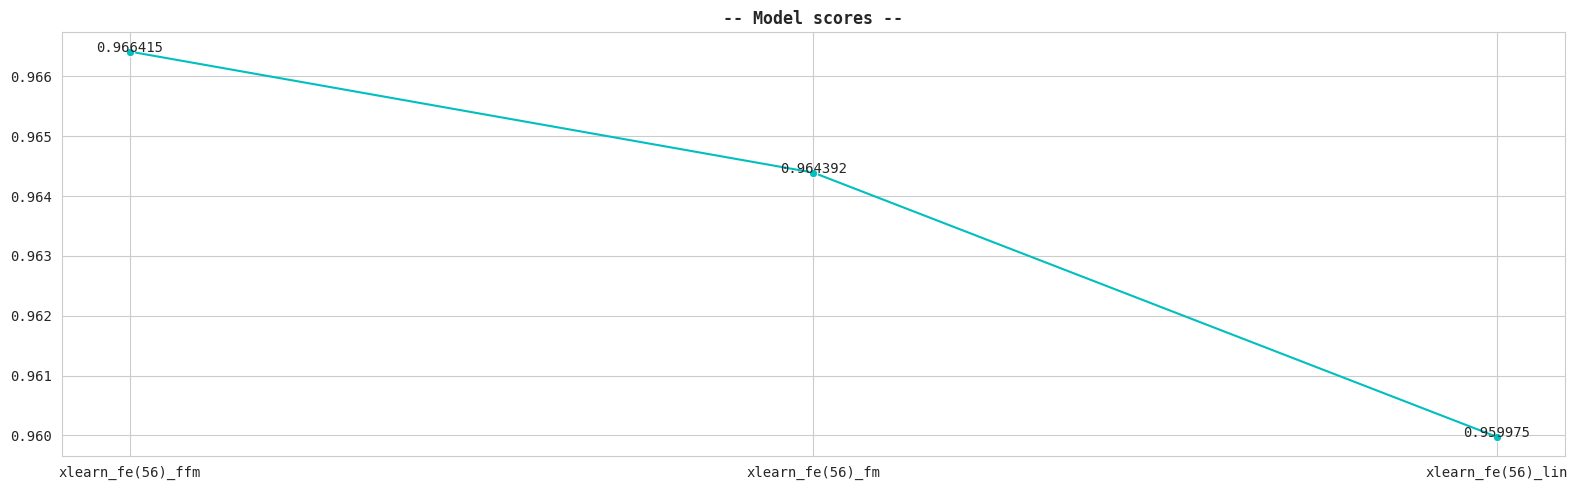

In [51]:
## -- Get Scores --

all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("-- Model scores --", fontweight="semibold")
ax.tick_params('x', rotation=0)

for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+1e-6, s, ha="center", va="baseline")

plt.tight_layout()
plt.show()

xlearn_fe(56)_ffm_966415 saved!


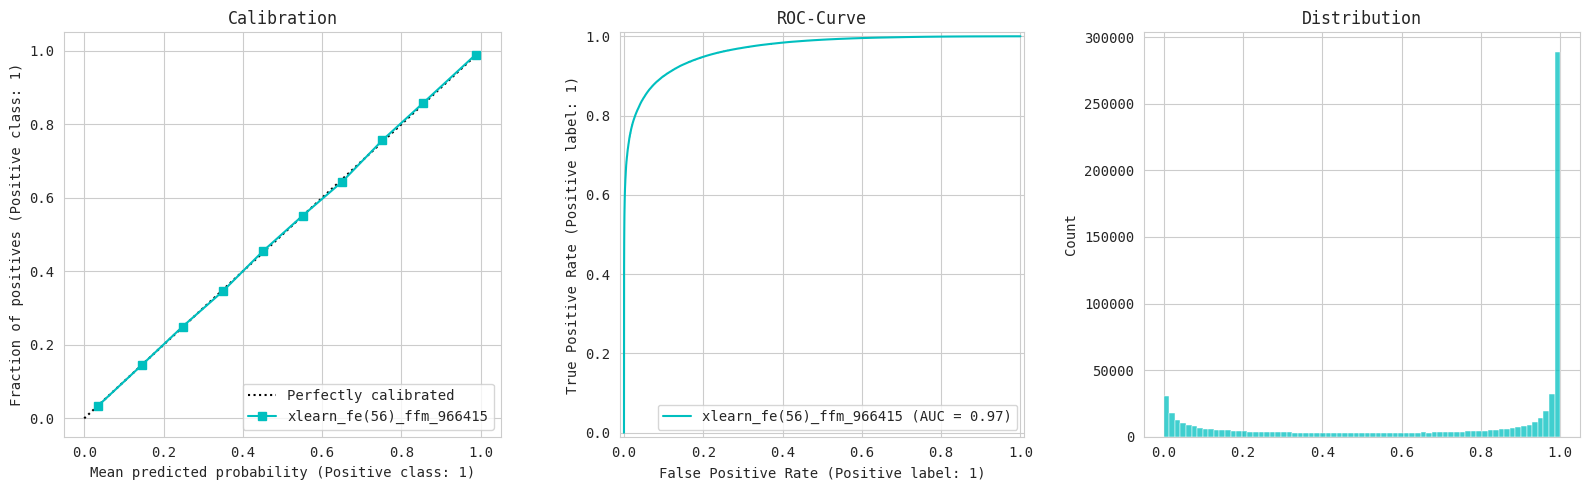


xlearn_fe(56)_fm_964392 saved!


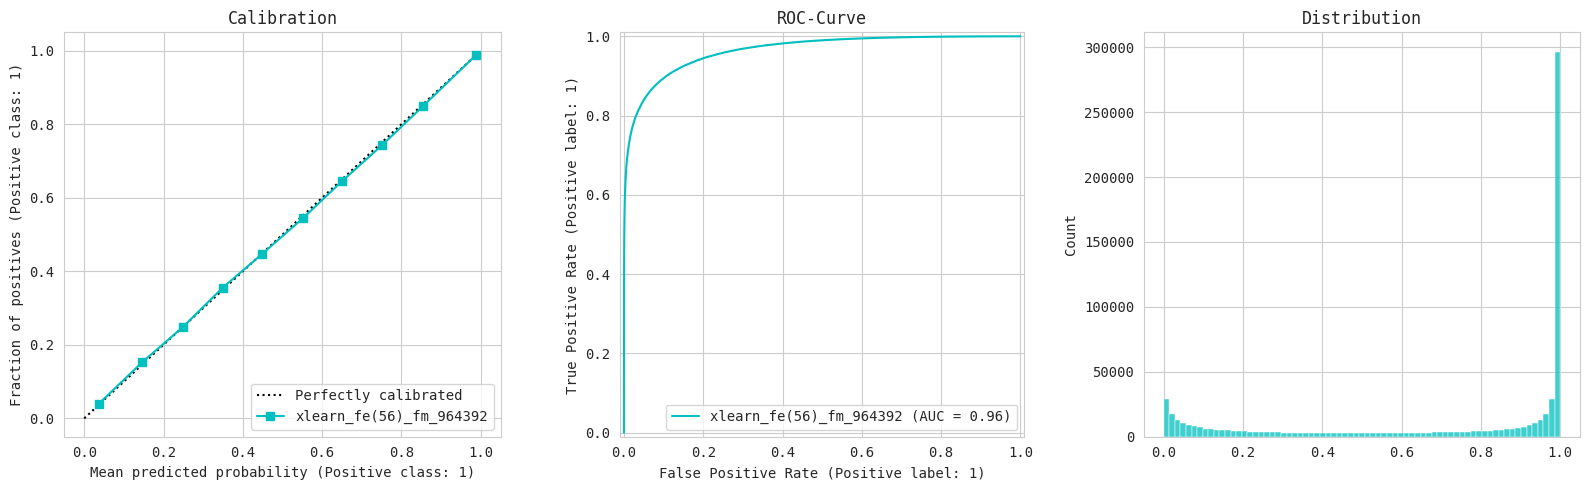


xlearn_fe(56)_lin_959975 saved!


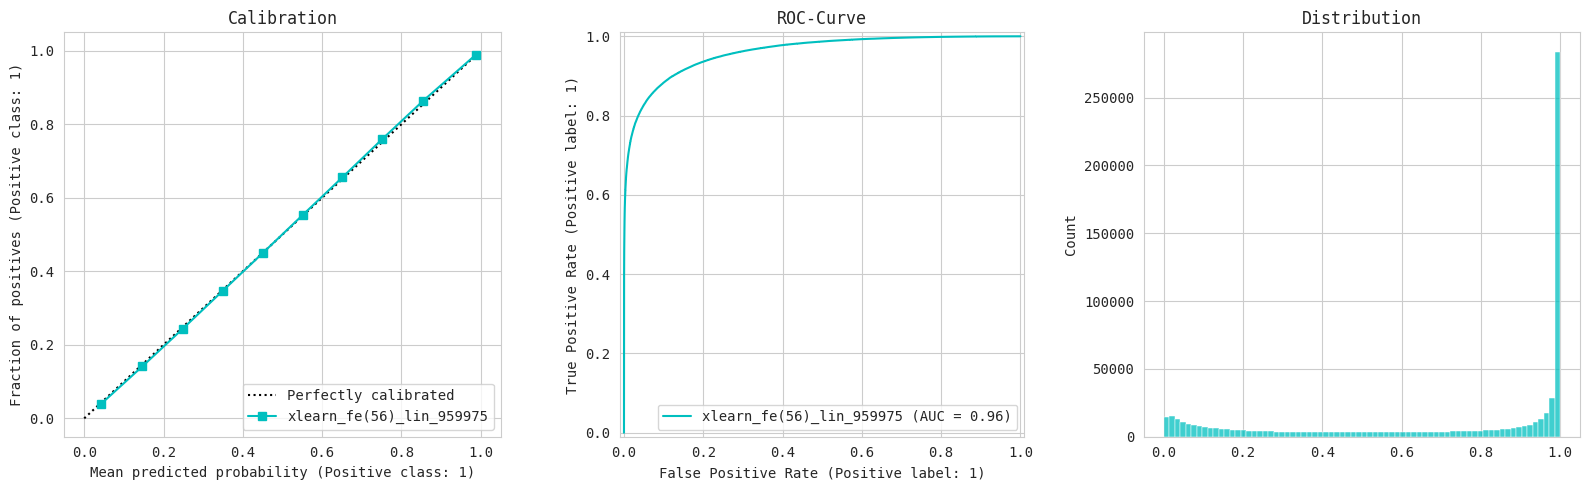

In [52]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title("Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title("ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title("Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [53]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

xlearn_fe(56)_ffm_966415 saved! (296302,)
xlearn_fe(56)_fm_964392 saved! (296302,)
xlearn_fe(56)_lin_959975 saved! (296302,)


In [54]:
pd.DataFrame(model_results)

,xlearn_fe(56)_ffm_966415,xlearn_fe(56)_fm_964392,xlearn_fe(56)_lin_959975
0,0.999606,0.999699,0.999266
1,0.976812,0.970994,0.973403
2,0.859795,0.753060,0.827457
3,0.995977,0.995243,0.987239
4,0.998632,0.999100,0.998935
...,...,...,...
296297,0.999995,0.999999,0.999999
296298,0.672897,0.527970,0.757433
296299,0.243671,0.387156,0.213361
296300,0.842569,0.913004,0.811871


In [55]:
# !rm -r /kaggle/working/